<a href="https://colab.research.google.com/github/DaffaAiraAdrn/DaffaAiraAdrin_2411531006_ML2526/blob/main/Praktikum4/TugasRegularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [ ]:
DATA_PATH = "/content/advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

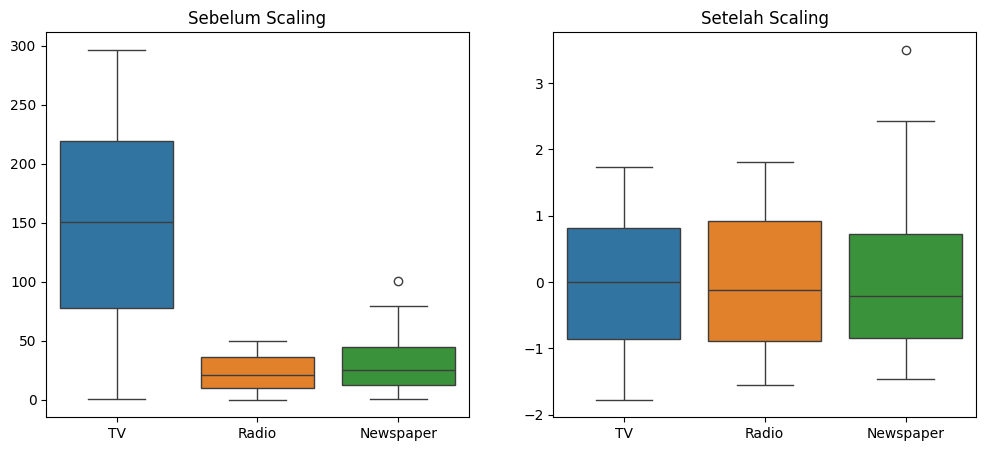

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
sns.boxplot(data=X_train[['TV', 'Radio', 'Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV', 'Radio', 'Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")
plt.show()

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print(f"perbedaan nilai loss antara train dan test: {abs(rmse_train_lr - rmse_test_lr)}")
print("Linear Regression")
print("RMSE train: ", rmse_train_lr)
print("RMSE test: ", rmse_test_lr)
print("Coefficients: ", lr.coef_)

perbedaan nilai loss antara train dan test: 0.06932261739706735
Linear Regression
RMSE train:  1.6358920055378559
RMSE test:  1.7052146229349232
Coefficients:  [4.58720774 1.48984025 0.08791597]


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print(f"Perbedaan nilai loss RIDGE antara train dan test: {abs(rmse_train_ridge - rmse_test_ridge)}")
print("\nRidge Regression (alpha = 1.0)")
print("RMSE train: ", rmse_train_ridge)
print("RMSE test: ", rmse_test_ridge)
print("Coefficients: ", ridge.coef_)


Perbedaan nilai loss RIDGE antara train dan test: 0.07126864964375312

Ridge Regression (alpha = 1.0)
RMSE train:  1.6361615871481854
RMSE test:  1.7074302367919385
Coefficients:  [4.55913661 1.48074139 0.0914114 ]


In [ ]:
lasso = Lasso(alpha=.1  )
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print(f"Perbedaan nilai loss LASSO antara train dan test: {abs(rmse_train_lasso - rmse_test_lasso)}")
print("\nLasso Regression (alpha=0.1)")
print("RMSE train:", rmse_train_lasso)
print("RMSE test:", rmse_test_lasso)
print("Coefficients: ", lasso.coef_)

Perbedaan nilai loss LASSO antara train dan test: 0.0687360357310236

Lasso Regression (alpha=0.1)
RMSE train: 1.643031487122971
RMSE test: 1.7117675228539946
Coefficients:  [4.49218143 1.42301597 0.01566227]



RIDGE:
index 0: (np.float64(1.6358920058108408), np.float64(1.7052165651052145))
Koefisien Ridge: [2.83952771 0.94697692 0.20427121]

RIDGE:
index 1: (np.float64(1.6358920328332522), np.float64(1.7052340696093304))
Koefisien Ridge: [2.83952771 0.94697692 0.20427121]

RIDGE:
index 2: (np.float64(1.6358947320033677), np.float64(1.705411583446725))
Koefisien Ridge: [2.83952771 0.94697692 0.20427121]

RIDGE:
index 3: (np.float64(1.6361615871481854), np.float64(1.7074302367919385))
Koefisien Ridge: [2.83952771 0.94697692 0.20427121]

RIDGE:
index 4: (np.float64(1.6598991216557328), np.float64(1.7487600326185369))
Koefisien Ridge: [2.83952771 0.94697692 0.20427121]

RIDGE:
index 5: (np.float64(2.4666177681545713), np.float64(2.6763008441217013))
Koefisien Ridge: [2.83952771 0.94697692 0.20427121]

LASSO
index 0: (np.float64(1.6358927178485096), np.float64(1.7051839633788652))
Koefisien Lasso: [0. 0. 0.]

LASSO
index 1: (np.float64(1.6359635277252735), np.float64(1.70502978276369))
Koefisien

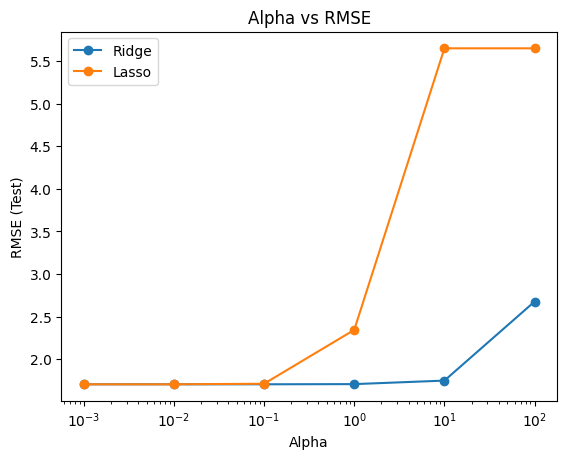

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]


ridge_rmse_train = []
lasso_rmse_train = []
ridge_rmse = []
lasso_rmse = []

for a in alphas:
  r = Ridge(alpha = a).fit(X_train_scaled, y_train)
  l = Lasso(alpha= a).fit(X_train_scaled, y_train)

  ridge_rmse_train.append(np.sqrt(mean_squared_error(y_train, r.predict(X_train_scaled))))
  lasso_rmse_train.append(np.sqrt(mean_squared_error(y_train, l.predict(X_train_scaled))))
  ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
  lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

for i, (a, b) in enumerate(zip(ridge_rmse_train, ridge_rmse)):
    print("\nRIDGE:")
    print(f"index {i}: {a, b}")
    print(f"Koefisien Ridge: {r.coef_}")

for i, (a,b) in enumerate(zip(lasso_rmse_train, lasso_rmse)):
  print("\nLASSO")
  print(f"index {i}: {a, b}")
  print(f"Koefisien Lasso: {l.coef_}")


plt.plot(alphas, ridge_rmse, marker='o', label="Ridge")
plt.plot(alphas, lasso_rmse, marker='o', label = "Lasso")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")
plt.show()

In [ ]:
alphas = [0.002, 0.05, 0.1, .5, 2, 50]

ridge_coefs = []
lasso_coefs = []

for a in alphas:
  r = Ridge(alpha = a).fit(X_train_scaled, y_train)
  l = Lasso(alpha=a).fit(X_train_scaled, y_train)

  ridge_coefs.append(r.coef_)
  lasso_coefs.append(l.coef_)


ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

feature_names = X.columns

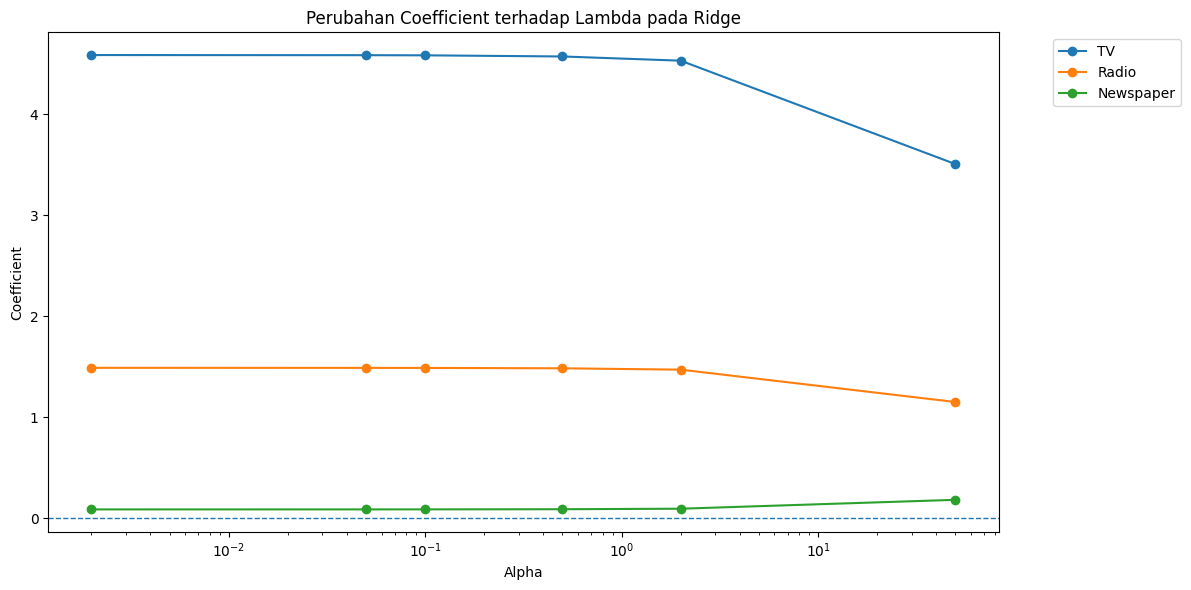

In [ ]:
plt.figure(figsize=(12,6))

for i in range(ridge_coefs.shape[1]):
  plt.plot(alphas, ridge_coefs[:, i], marker = 'o', label=feature_names[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Perubahan Coefficient terhadap Lambda pada Ridge")
plt.axhline(0, linestyle="--", linewidth = 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

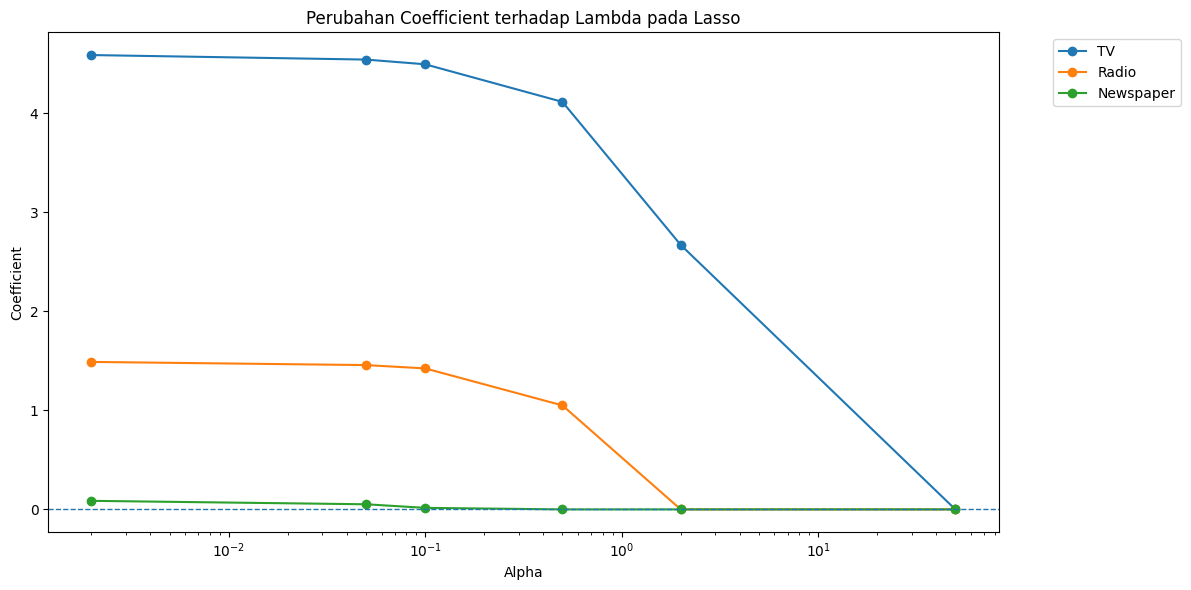

In [ ]:
plt.figure(figsize=(12,6))

for i in range(lasso_coefs.shape[1]):
  plt.plot(alphas, lasso_coefs[:, i], marker = 'o', label=feature_names[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Perubahan Coefficient terhadap Lambda pada Lasso")
plt.axhline(0, linestyle="--", linewidth = 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()